# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [87]:
#Import all the necessary modules
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.simplefilter('ignore')

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [11]:
pima_df= pd.read_csv("C:\AIML\Assessment\R4\LAB\pima-indians-diabetes.csv")
pima_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
colnames = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']
pima_df= pd.read_csv("C:\AIML\Assessment\R4\LAB\pima-indians-diabetes-2.data", names=colnames)
pima_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

# Q2. Print 10 samples from the dataset

In [15]:
pima_df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [16]:
pima_df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
506,0,180,90,26,90,36.5,0.314,35,1
297,0,126,84,29,215,30.7,0.520,24,0
481,0,123,88,37,0,35.2,0.197,29,0
672,10,68,106,23,49,35.5,0.285,47,0
28,13,145,82,19,110,22.2,0.245,57,0
201,1,138,82,0,0,40.1,0.236,28,0
732,2,174,88,37,120,44.5,0.646,24,1
616,6,117,96,0,0,28.7,0.157,30,0
82,7,83,78,26,71,29.3,0.767,36,0
34,10,122,78,31,0,27.6,0.512,45,0


# Q3 Print the datatypes of each column and the shape of the dataset 

In [17]:
pima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
Pregnancies      768 non-null int64
Glucose          768 non-null int64
BloodPressure    768 non-null int64
SkinThickness    768 non-null int64
Insulin          768 non-null int64
BMI              768 non-null float64
Pedigree         768 non-null float64
Age              768 non-null int64
Outcome          768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [23]:
pima_df.dtypes

Pregnancies        int64
Glucose            int64
BloodPressure      int64
SkinThickness      int64
Insulin            int64
BMI              float64
Pedigree         float64
Age                int64
Outcome            int64
dtype: object

In [44]:
print("Shape of Pima Diabetes dataframe:", pima_df.shape)

Shape of Pima Diabetes dataframe: (768, 9)


In [24]:
pima_df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [25]:
pima_df[pima_df == 0].count()

Pregnancies      111
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Pedigree           0
Age                0
Outcome          500
dtype: int64

There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [65]:
missingval = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI','Pedigree']
for col in missingval:
    pima_df[col].replace(to_replace= 0,value = np.nan,inplace = True)
    pima_df[col].fillna(pima_df[col].median(),inplace=True)

In [66]:
pima_df[pima_df == 0].count()

Pregnancies      111
Glucose            0
BloodPressure      0
SkinThickness      0
Insulin            0
BMI                0
Pedigree           0
Age                0
Outcome          500
dtype: int64

In [74]:
#pima_df[missingval].isin([0]).sum()

for col in pima_df.columns[0:8]:
    if(pima_df[col].isin([0]).sum() > 0):
        print('Attribute ',col,'has zero values')


Attribute  Pregnancies has zero values


# Q5 Print the descriptive statistics of each & every column using describe() function

In [75]:
pima_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
Pedigree,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

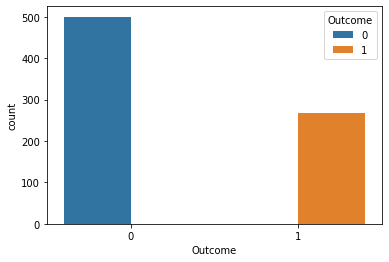

In [79]:
sns.countplot(x="Outcome",  data=pima_df, hue='Outcome')

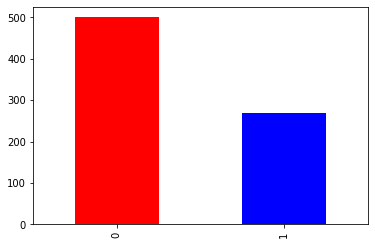

In [81]:
pima_df["Outcome"].value_counts().plot(kind="bar", color=["red", "blue"]);

In [86]:
pima_df.groupby(["Outcome"]).count()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age
Outcome,,,,,,,,
0,500,500,500,500,500,500,500,500
1,268,268,268,268,268,268,268,268


In [310]:
pima_df.skew()

Pregnancies      0.901674
Glucose          0.535587
BloodPressure    0.141885
SkinThickness    0.837608
Insulin          3.380019
BMI              0.599233
Pedigree         1.919911
Age              1.129597
Outcome          0.635017
dtype: float64

#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


C:\Anaconda\lib\site-packages\statsmodels\nonparametric\kde.py:487: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\Anaconda\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


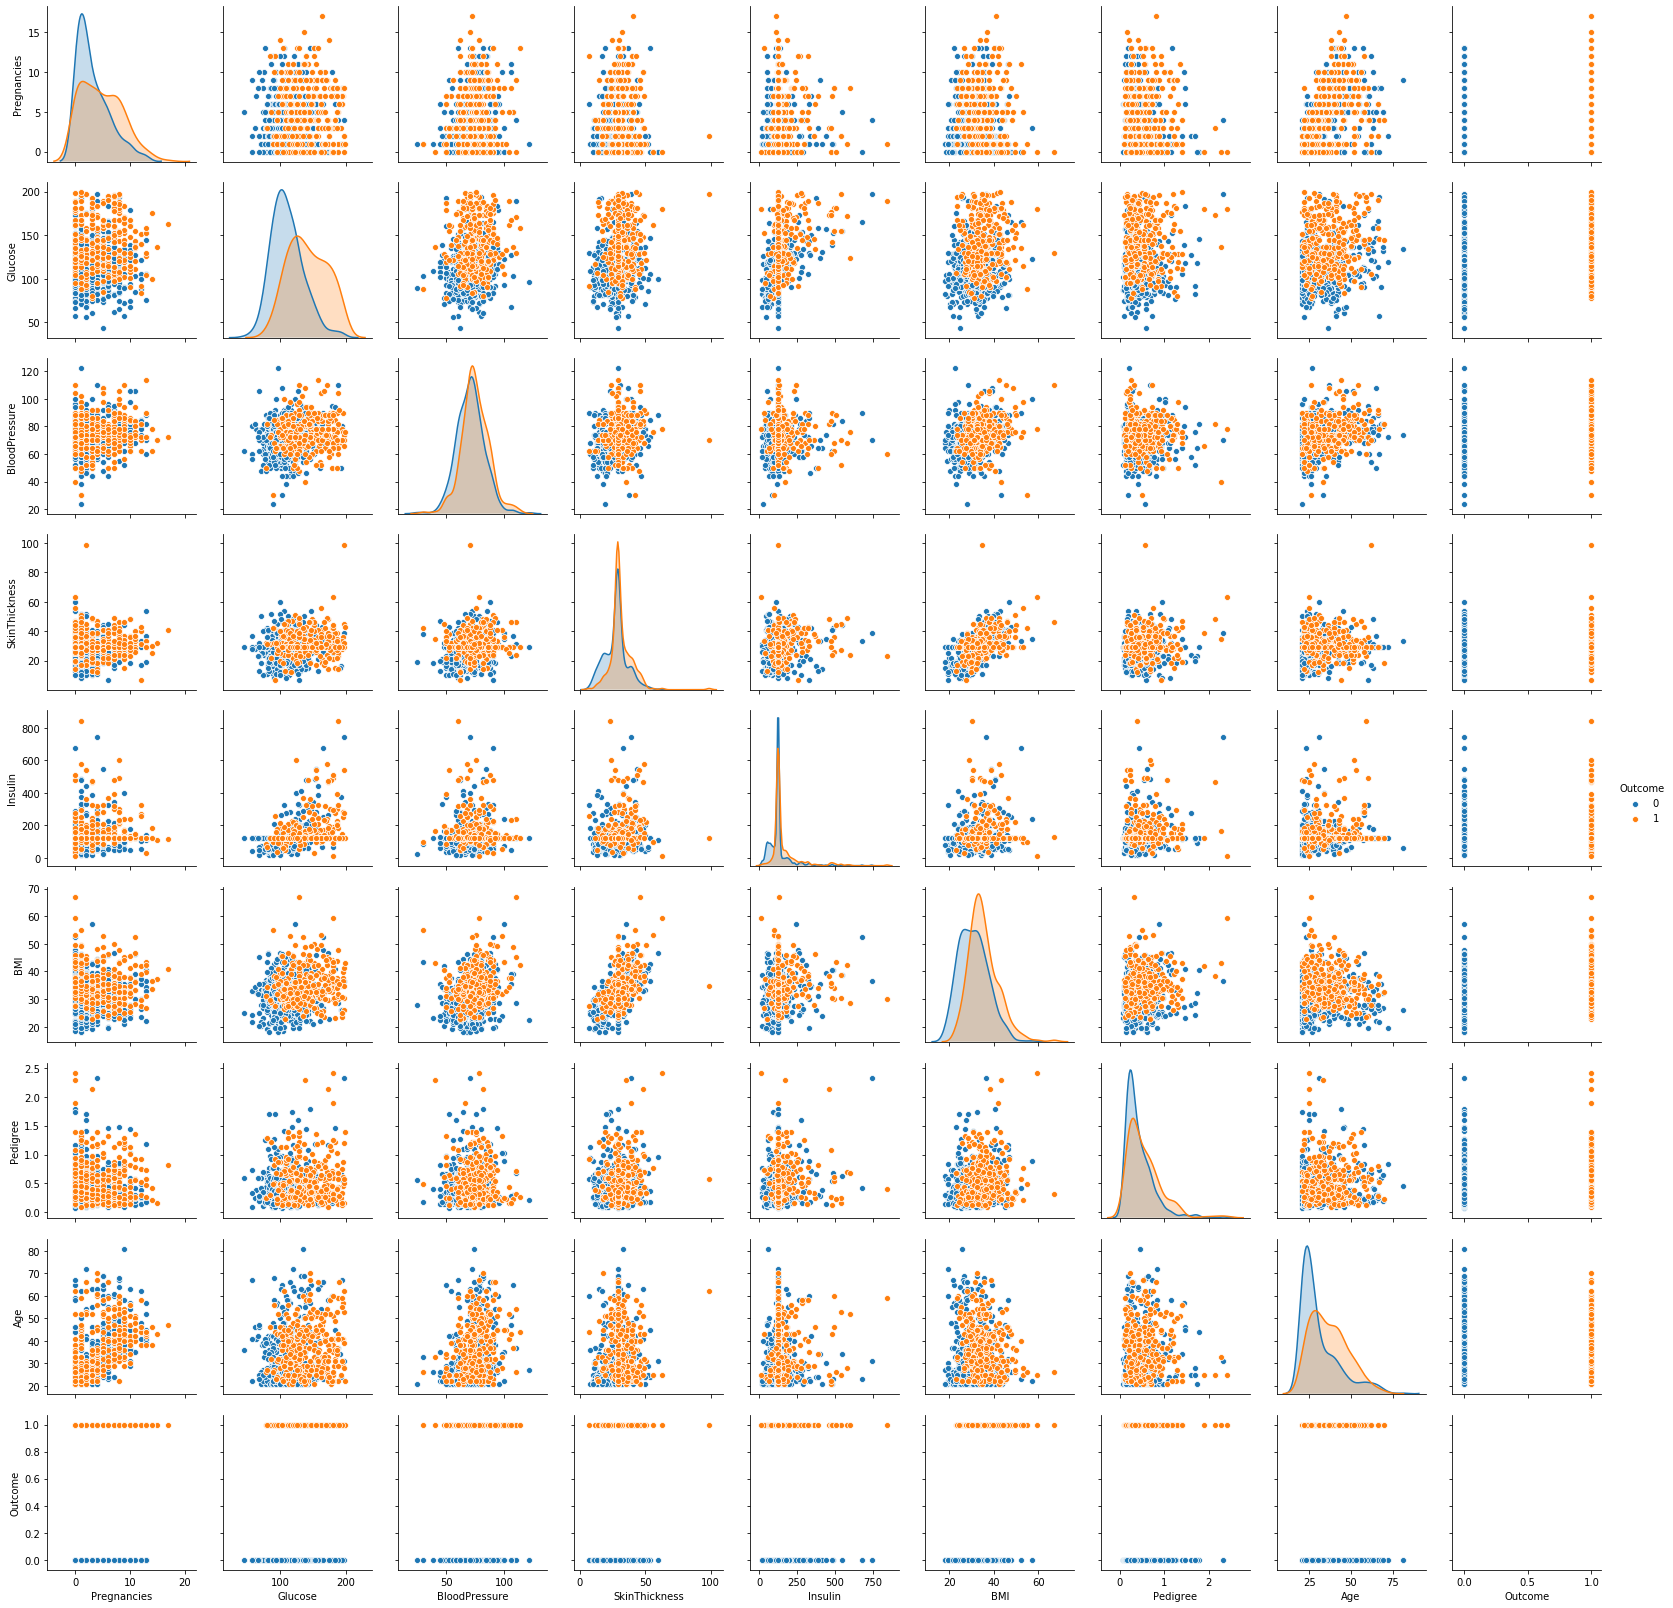

In [85]:
from matplotlib import pyplot as plt
sns.pairplot(pima_df,diag_kind='kde',hue='Outcome')

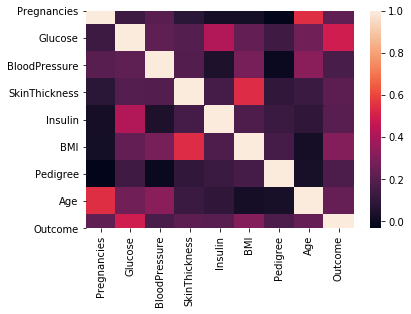

In [88]:
sns.heatmap(pima_df.corr())

Using the plot - infer the relationship between different variables

# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [137]:
X=pima_df.drop('Outcome',axis=1)
y=pima_df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,random_state=5)

In [129]:
# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 537 samples.
Testing set has 231 samples.


# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [138]:
from sklearn.tree import DecisionTreeClassifier
DT_Classifier=DecisionTreeClassifier(criterion='entropy',max_depth=5)

In [140]:
DT_Classifier.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=5,
                       max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort=False,
                       random_state=None, splitter='best')

# Q10 Print the accuracy of the model & print the confusion matrix 

In [180]:
print("The DecisionTree Classifier Training Accuracy", DT_Classifier.score(X_train,y_train))
print("The DecisionTree Classifier Testing Accuracy", DT_Classifier.score(X_test,y_test))

The DecisionTree Classifier Training Accuracy 0.7988826815642458
The DecisionTree Classifier Testing Accuracy 0.7835497835497836


In [142]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_score,recall_score,f1_score
predicted = DT_Classifier.predict(X_test)
print(confusion_matrix(y_test,predicted))
print("The Metrics are")
print("Precision Score:", precision_score(y_test,predicted,average=None))
print("Recall Score:", recall_score(y_test,predicted,average=None))
print("F1 Score:", f1_score(y_test,predicted,average=None))

[[142  18]
 [ 32  39]]
The Metrics are
Precision Score: [0.81609195 0.68421053]
Recall Score: [0.8875     0.54929577]
F1 Score: [0.8502994 0.609375 ]


In [143]:
print(classification_report(y_test,predicted))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       160
           1       0.68      0.55      0.61        71

    accuracy                           0.78       231
   macro avg       0.75      0.72      0.73       231
weighted avg       0.78      0.78      0.78       231



# Q11 Print the feature importance of the decision model

In [144]:
DT_Classifier.feature_importances_

array([0.04995606, 0.47527995, 0.01950321, 0.04576889, 0.        ,
       0.15593915, 0.09937852, 0.15417421])

# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [177]:
from sklearn.ensemble import RandomForestClassifier
RF_Classifier=RandomForestClassifier(n_estimators=12,max_depth=4)

In [178]:
RF_Classifier.fit(X_train,y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=4, max_features='auto', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=12,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [179]:
print("The RandomForest Classifier Training Accuracy", RF_Classifier.score(X_train,y_train))
print("The RandomForest Classifier Testing Accuracy", RF_Classifier.score(X_test,y_test))

The RandomForest Classifier Training Accuracy 0.8100558659217877
The RandomForest Classifier Testing Accuracy 0.7878787878787878


# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [187]:
from sklearn.ensemble import AdaBoostClassifier
AB_Classifier = AdaBoostClassifier(n_estimators=12,random_state=7)

In [188]:
AB_Classifier.fit(X_train,y_train)

AdaBoostClassifier(algorithm='SAMME.R', base_estimator=None, learning_rate=1.0,
                   n_estimators=12, random_state=7)

In [190]:
print("The AdaBoost Classifier Training Accuracy", AB_Classifier.score(X_train,y_train))
print("The AdaBoost Classifier Testing Accuracy", AB_Classifier.score(X_test,y_test))

The AdaBoost Classifier Training Accuracy 0.8119180633147114
The AdaBoost Classifier Testing Accuracy 0.8008658008658008


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [261]:
from sklearn.ensemble import BaggingClassifier
BG_Classifier = BaggingClassifier(n_estimators=30,random_state=1)

In [262]:
BG_Classifier.fit(X_train,y_train)

BaggingClassifier(base_estimator=None, bootstrap=True, bootstrap_features=False,
                  max_features=1.0, max_samples=1.0, n_estimators=30,
                  n_jobs=None, oob_score=False, random_state=1, verbose=0,
                  warm_start=False)

In [263]:
print("The Bagging Classifier Training Accuracy", BG_Classifier.score(X_train,y_train))
print("The Bagging Classifier Testing Accuracy", BG_Classifier.score(X_test,y_test))

The Bagging Classifier Training Accuracy 0.9981378026070763
The Bagging Classifier Testing Accuracy 0.7662337662337663


###### With the default hyperparameters and without base estimator, the model is overfitted. Let's try with base_estimator.

In [271]:
base_class=RandomForestClassifier(n_estimators=10,max_depth=4)
BG1_Classifier = BaggingClassifier(base_estimator=base_class, n_estimators=10)

In [272]:
BG1_Classifier.fit(X_train,y_train)

BaggingClassifier(base_estimator=RandomForestClassifier(bootstrap=True,
                                                        class_weight=None,
                                                        criterion='gini',
                                                        max_depth=4,
                                                        max_features='auto',
                                                        max_leaf_nodes=None,
                                                        min_impurity_decrease=0.0,
                                                        min_impurity_split=None,
                                                        min_samples_leaf=1,
                                                        min_samples_split=2,
                                                        min_weight_fraction_leaf=0.0,
                                                        n_estimators=10,
                                                        n_jobs=None,
           

In [276]:
print("The Bagging Classifier with Random Forrest base classifier Training Accuracy", BG1_Classifier.score(X_train,y_train))
print("The Bagging Classifier with Random Forrest base classifier Testing Accuracy", BG1_Classifier.score(X_test,y_test))

The Bagging Classifier with Random Forrest base classifier Training Accuracy 0.8156424581005587
The Bagging Classifier with Random Forrest base classifier Testing Accuracy 0.7922077922077922


# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [297]:
from sklearn.ensemble import GradientBoostingClassifier
GB_Classifier = GradientBoostingClassifier(n_estimators=10,random_state=7,max_depth=3)

In [298]:
GB_Classifier.fit(X_train,y_train)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='deviance', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_impurity_split=None,
                           min_samples_leaf=1, min_samples_split=2,
                           min_weight_fraction_leaf=0.0, n_estimators=10,
                           n_iter_no_change=None, presort='auto',
                           random_state=7, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [299]:
print("The GradientBoost Classifier Training Accuracy", GB_Classifier.score(X_train,y_train))
print("The GradientBoost Classifier Testing Accuracy", GB_Classifier.score(X_test,y_test))

The GradientBoost Classifier Training Accuracy 0.7839851024208566
The GradientBoost Classifier Testing Accuracy 0.7835497835497836


In [300]:
models = []
models.append(('DT', DT_Classifier))
models.append(('RF', RF_Classifier))
models.append(('Ada', AB_Classifier))
models.append(('BAGGING', BG_Classifier))
models.append(('GB', GB_Classifier))

DT: 0.624220 (0.096213)
RF: 0.616071 (0.072680)
Ada: 0.596491 (0.096365)
BAGGING: 0.609357 (0.105614)
GB: 0.530100 (0.077643)


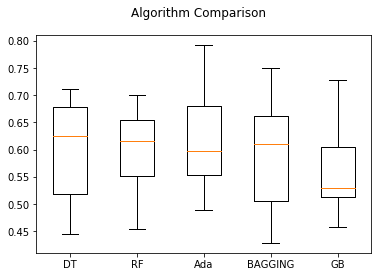

In [304]:
# evaluate each model in turn
from sklearn import model_selection
results = []
names = []
scoring = 'f1'
for name, model in models:
    kfold = model_selection.KFold(n_splits=10,random_state=42)
    cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, np.median(cv_results), cv_results.std())
    print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.

In [306]:
from sklearn.ensemble import VotingClassifier
vc = VotingClassifier(estimators = [('DT',DT_Classifier),('RF',RF_Classifier),('Ada', AB_Classifier),('BAGGING',BG_Classifier ),('GB',GB_Classifier)],voting='soft')

In [309]:
vc.fit(X_train,y_train)
print("The Voting Classifier Training Accuracy")
print(vc.score(X_train,y_train))
print("The Voting Classifier Testing Accuracy")
print(vc.score(X_test,y_test))
predicted = vc.predict(X_test)
print(confusion_matrix(y_test,predicted))
print(classification_report(y_test,predicted))

The Voting Classifier Training Accuracy
0.8212290502793296
The Voting Classifier Testing Accuracy
0.7835497835497836
[[135  25]
 [ 25  46]]
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       160
           1       0.65      0.65      0.65        71

    accuracy                           0.78       231
   macro avg       0.75      0.75      0.75       231
weighted avg       0.78      0.78      0.78       231

